In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

                               [0, 0, 1]  [0, 0, 2]  [0, 0, 3]  [0, 0, 4]  \
cheap,average,unreliable           0.326      0.326      0.326      0.326   
cheap,average,average              0.300      0.300      0.300      0.300   
cheap,fast,unreliable              0.036      0.036      0.036      0.036   
cheap,slow,average                 0.166      0.166      0.166      0.166   
cheap,average,highly-reliable      0.036      0.036      0.036      0.036   

                               [0, 0, 5]  [0, 0, 6]  [0, 1, 0]  [0, 1, 1]  \
cheap,average,unreliable           0.326      0.326      0.326      0.024   
cheap,average,average              0.300      0.300      0.300      0.228   
cheap,fast,unreliable              0.036      0.036      0.036      0.032   
cheap,slow,average                 0.166      0.166      0.166      0.000   
cheap,average,highly-reliable      0.036      0.036      0.036      0.154   

                               [0, 1, 2]  [0, 1, 3]  ...  [6, 5, 4]  \
che

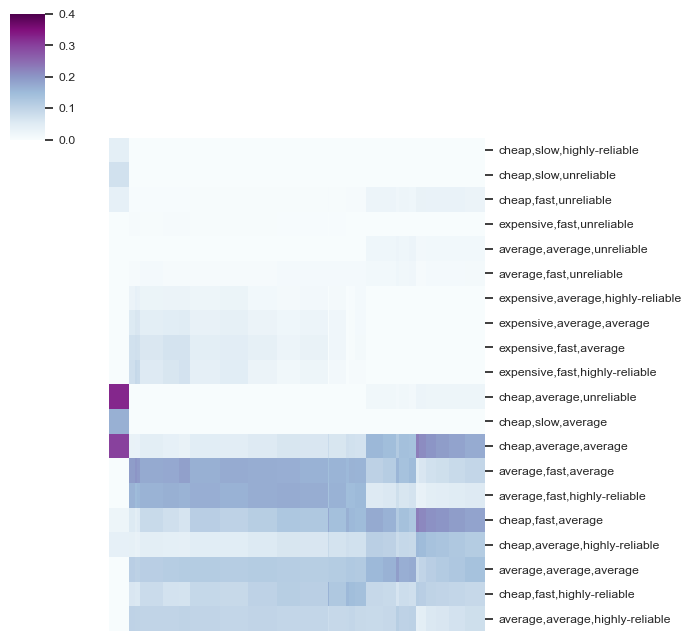

In [111]:
df = pd.read_csv('./data/robustness_matrix.csv', index_col=0)
print(df.head())

#plt.figure(figsize=(8,8))
#ax = sns.heatmap(df, cmap='BuPu', vmin=0, vmax=1, linewidths=0.5)
sns.set(font_scale=0.8)
ax = sns.clustermap(df, cmap='BuPu', robust=True, method="average", vmin=0, vmax=0.4, 
                    figsize=(7,7))
ax.ax_row_dendrogram.set_visible(False)
ax.ax_col_dendrogram.set_visible(False)
ax.ax_heatmap.set_xticklabels([])

#ax.set_xlabel('configurations')
#ax.set_ylabel('tradeoffs')
#ax.set_xticks([])
#ax.set_yticks([])
plt.show()


In [113]:
#dir(ax)

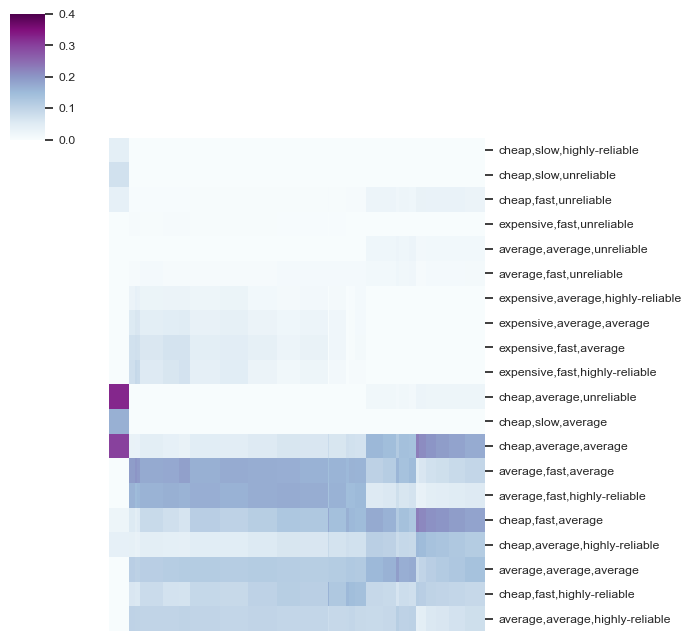

In [116]:
from scipy.spatial import distance
from scipy.cluster import hierarchy

correlations_array = df.values
row_linkage = hierarchy.linkage(distance.pdist(correlations_array), method='average')
col_linkage = hierarchy.linkage(distance.pdist(correlations_array.T), method='average')

#sns.set(font_scale=0.8)
ax = sns.clustermap(df, row_linkage=row_linkage, col_linkage=col_linkage, 
                    vmax=0.4, vmin=0, method="average", figsize=(7, 7), cmap="BuPu")
ax.ax_row_dendrogram.set_visible(False)
ax.ax_col_dendrogram.set_visible(False)
ax.ax_heatmap.set_xticklabels([])
plt.show()

In [117]:
col_linkage

array([[0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 2.00000000e+00],
       [2.00000000e+00, 3.42000000e+02, 0.00000000e+00, 3.00000000e+00],
       [3.00000000e+00, 3.43000000e+02, 0.00000000e+00, 4.00000000e+00],
       ...,
       [6.76000000e+02, 6.78000000e+02, 9.94239706e-02, 1.08000000e+02],
       [6.79000000e+02, 6.80000000e+02, 2.25988971e-01, 3.24000000e+02],
       [6.55000000e+02, 6.81000000e+02, 5.27520520e-01, 3.42000000e+02]])

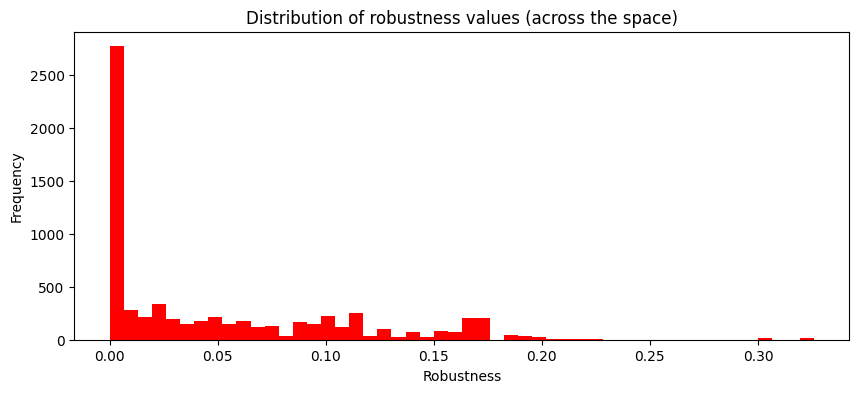

In [29]:
df.stack().plot.hist(bins=50, figsize=(10, 4), color='red')
plt.xlabel('Robustness')
plt.title('Distribution of robustness values (across the space)')
plt.show()

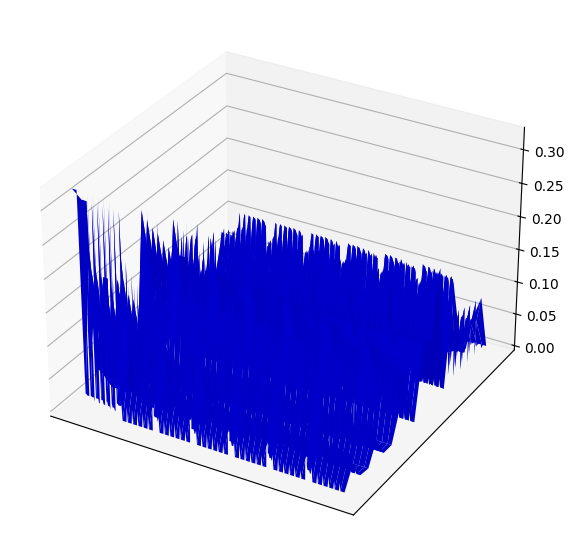

In [55]:
def z_func(x, y):
    z = 0.000855995633558468 * x ** 2 + 0.0102702516120239 * x + \
        0.00451027901725375 * y ** 2 - 2.23785431578513 * y + \
        251.029058292935
    return z

# Creates a 1D array of all possible x and y coordinates
#x_coords = np.linspace(-30, 30, 100)
#y_coords = np.linspace(180, 220, 100)
x_coords = [x for x,_ in enumerate(df.columns)]
y_coords = [y for y,_ in enumerate(df.index)]

# Creates 2D array with all possible combinations of x and y coordinates,
# so x_grid.shape = (100, 100) and y_grid.shape = (100, 100)
[x_grid, y_grid] = np.meshgrid(x_coords, y_coords)

# Evaluates z at all grid points
#z_grid = z_func(x_grid, y_grid)
z_grid = df.values

# Plotting
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x_grid,y_grid,z_grid, color='blue')
ax.set_yticks([])
ax.set_xticks([])
plt.show()